**CREDICT CARD FRAUD DETECTION**


✅ STEP 1 — Import Libraries

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

✅ STEP 2 — Load Dataset

In [35]:
df = pd.read_csv("creditcard[1].csv")
column_names = ['Time', 'Amount', 'V1', 'V2', 'Class']
df.columns = column_names

print("Dataset Shape:", df.shape)
print("\nClass Distribution:\n", df['Class'].value_counts())

Dataset Shape: (199548, 5)

Class Distribution:
 Class
0    199260
1       288
Name: count, dtype: int64


✅ STEP 3-Preprocessing

In [36]:
# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# Standardize Amount and Time
scaler = StandardScaler()
X[['Amount', 'Time']] = scaler.fit_transform(X[['Amount', 'Time']])

✅ STEP 4 — Train-Test Split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Class Distribution:\n", y_train.value_counts())




Training Class Distribution:
 Class
0    159408
1       230
Name: count, dtype: int64


✅ STEP 5 — Handle Class Imbalance

In [38]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE Class Distribution:\n", pd.Series(y_train_resampled).value_counts())



After SMOTE Class Distribution:
 Class
0    159408
1    159408
Name: count, dtype: int64


✅ STEP 6 - Logistic Regression Model

In [39]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_resampled, y_train_resampled)

lr_pred = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]

print("\n===== Logistic Regression Results =====")
print(classification_report(y_test, lr_pred))

lr_roc = roc_auc_score(y_test, lr_proba)
print("ROC-AUC Score:", lr_roc)


===== Logistic Regression Results =====
              precision    recall  f1-score   support

           0       1.00      0.77      0.87     39852
           1       0.00      0.55      0.01        58

    accuracy                           0.77     39910
   macro avg       0.50      0.66      0.44     39910
weighted avg       1.00      0.77      0.87     39910

ROC-AUC Score: 0.7070877764971775


✅ STEP 7 —  Random Forest Model

In [40]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

✅ STEP 8 —  Random Forest Model

In [41]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_resampled, y_train_resampled)

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("\n===== Random Forest Results =====")
print(classification_report(y_test, rf_pred))

rf_roc = roc_auc_score(y_test, rf_proba)
print("ROC-AUC Score:", rf_roc)


===== Random Forest Results =====
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     39852
           1       0.04      0.26      0.07        58

    accuracy                           0.99     39910
   macro avg       0.52      0.62      0.53     39910
weighted avg       1.00      0.99      0.99     39910

ROC-AUC Score: 0.7832594824990395


✅ STEP 9 - Confusion Matrix (Random Forest)

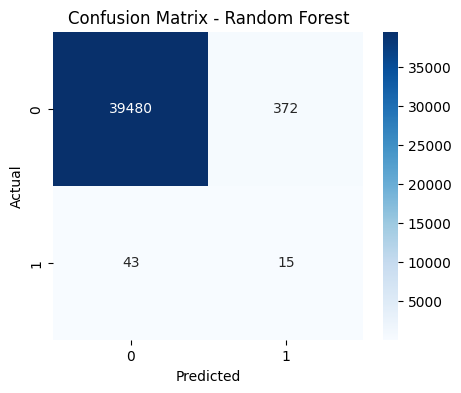

In [42]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


✅ STEP 9- Feature Importance (Random Forest)

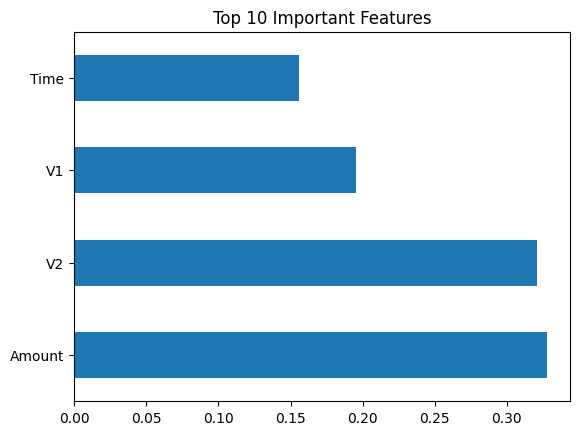

In [43]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()


✅ STEP 10 — Model Comparison

In [44]:
print("\n===== MODEL COMPARISON =====")
print("Logistic Regression ROC-AUC:", lr_roc)
print("Random Forest ROC-AUC:", rf_roc)


===== MODEL COMPARISON =====
Logistic Regression ROC-AUC: 0.7070877764971775
Random Forest ROC-AUC: 0.7832594824990395


**CONCLUSION**

The dataset was highly imbalanced, with very few fraudulent transactions.
SMOTE was applied to balance the classes.
Random Forest performed better than Logistic Regression with a higher ROC-AUC score.
Recall was prioritized to reduce missed fraud cases.
The final model effectively detects fraudulent transactions while maintaining good precision.